# Feature-mode experiment

**Nothing is trained here.** This reads what `experiment_mlp.ipynb` saved.

Do one run per feature mode first: set `FEATURES` in that notebook's vector cell, run
it end to end, and its test cell writes `runs/<mode>.npz` with the training history,
the per-frame predictions, and the two detector scores behind each frame.

| `FEATURES` | input | dims |
|---|---|---|
| `2d` | image x, y | 42 |
| `2.5d` | image x, y, z | 63 |
| `3d` | wrist-relative world | 63 |
| `2d+3d` | x, y + world | 105 |
| `2.5d+3d` | x, y, z + world | 126 |

Every percentage below is out of **every frame filmed**, never out of the survivors of
the stage before. A frame the palm detector missed is a letter the user could not
sign, so it counts as wrong. The one exception is labelled *of confirmed*, which is
the classifier marked only on the frames it was handed landmarks for.

Set `REPORT` to `None` for every mode, or to one mode name to narrow the plots.

In [10]:
# --- Load the runs ----------------------------------------------------------------
# palm and presence are properties of the capture, not of the model, so they are the
# same frames in every run; the asserts below refuse to compare runs that disagree,
# which is what happens if the cache was rebuilt between two modes.
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RUNS_DIR = Path("runs")             # written by experiment_mlp.ipynb
REPORT = None                       # None = every mode, or "2d", "3d", "2d+3d", ...
PALM_MIN, PRESENCE_MIN = 0.5, 0.5   # jazz's own, and jazz rejects with <, so >= here

runs, stale = {}, []
for f in sorted(RUNS_DIR.glob("*.npz")):
    d = np.load(f)
    if "palm" in d.files:
        runs[str(d["features"])] = d
    else:
        stale.append(f.name)        # saved before the test set and the gates changed
assert runs, f"no current runs in {RUNS_DIR}/ -- run experiment_mlp.ipynb end to end"
assert REPORT is None or REPORT in runs, f"REPORT must be one of {list(runs)}"
if stale:
    print(f"ignoring {len(stale)} run(s) from before the rebuild: {', '.join(stale)}\n")


def stats(d):
    """One run -> its four numbers, every one of them over every frame filmed."""
    found = d["palm"] >= PALM_MIN
    sure = found & (d["presence"] >= PRESENCE_MIN)
    hit = d["y_true"] == d["y_pred"]
    return {"dims": int(d["dims"]), "epochs": len(d["history"]),
            "val": float(d["best_val"]), "palm": found.mean(),
            "confirmed": sure.mean(), "correct": hit.mean(),
            "of confirmed": hit.sum() / sure.sum()}


TABLE = pd.DataFrame({m: stats(d) for m, d in runs.items()}).T
TABLE = TABLE.sort_values("correct", ascending=False)
RANKED = list(TABLE.index)
MODES = RANKED if REPORT is None else [REPORT]
TRUTH = runs[RANKED[0]]["y_true"]
N = len(TRUTH)

assert all(np.array_equal(runs[m]["y_true"], TRUTH) for m in RANKED), \
    "modes were scored on different test sets"
assert np.allclose(TABLE["confirmed"], TABLE["confirmed"].iloc[0]), \
    "modes disagree on detection, so they did not all read the same cache"

pct = {c: "{:.2%}".format for c in
       ("val", "palm", "confirmed", "correct", "of confirmed")}
print(f"{N:,} frames in the held-out capture, {len(runs)} modes, best first\n")
print(TABLE.to_string(formatters={"dims": "{:.0f}".format,
                                  "epochs": "{:.0f}".format, **pct}))

ignoring 3 run(s) from before the rebuild: 3d+dir.npz, cnn+3d+dir.npz, hier+3d+dir.npz

3,744 frames in the held-out capture, 5 modes, best first

        dims epochs    val   palm confirmed correct of confirmed
2d+3d    105     93 99.67% 92.95%    87.26%  76.50%       87.66%
2.5d+3d  126    118 99.72% 92.95%    87.26%  76.42%       87.57%
2d        42     84 99.63% 92.95%    87.26%  76.18%       87.30%
2.5d      63    124 99.68% 92.95%    87.26%  75.96%       87.05%
3d        63     89 99.58% 92.95%    87.26%  75.08%       86.04%


## 1. Where the frames go

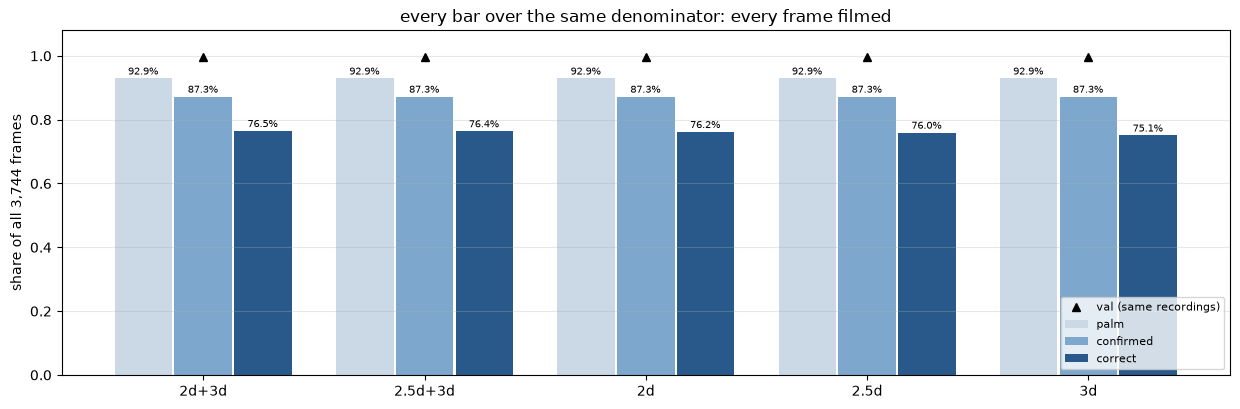

In [11]:
# Three bars over one denominator, so they can only ever go down: the frames a palm
# was found in, the frames a hand was then confirmed in, and the frames the letter
# came out right. The gap between the last two bars is the classifier's fault; the gap
# before them belongs to a detector this project does not train.
x = np.arange(len(RANKED))
fig, ax = plt.subplots(figsize=(1.9 * len(RANKED) + 3, 4.2))
for off, col, shade in ((-0.27, "palm", "#cbd8e6"), (0.0, "confirmed", "#7da7cc"),
                        (0.27, "correct", "#28598a")):
    ax.bar(x + off, TABLE[col], 0.26, label=col, color=shade)
    for k, v in enumerate(TABLE[col]):
        ax.text(k + off, v + 0.012, f"{v:.1%}", ha="center", fontsize=7.5)
# Validation is a split of the same recordings, where a frame's near-twin sits in
# train, so it is drawn as a reminder of the gap rather than as a comparable bar.
ax.plot(x, TABLE["val"], "k^", ms=6, ls="none", label="val (same recordings)")
ax.set_xticks(x, RANKED)
ax.set_ylim(0, 1.08)
ax.set_ylabel(f"share of all {N:,} frames")
ax.set_title("every bar over the same denominator: every frame filmed")
ax.grid(axis="y", alpha=0.3)
ax.legend(loc="lower right", fontsize=8)
fig.tight_layout()
plt.show()

## 2. Loss and accuracy per epoch

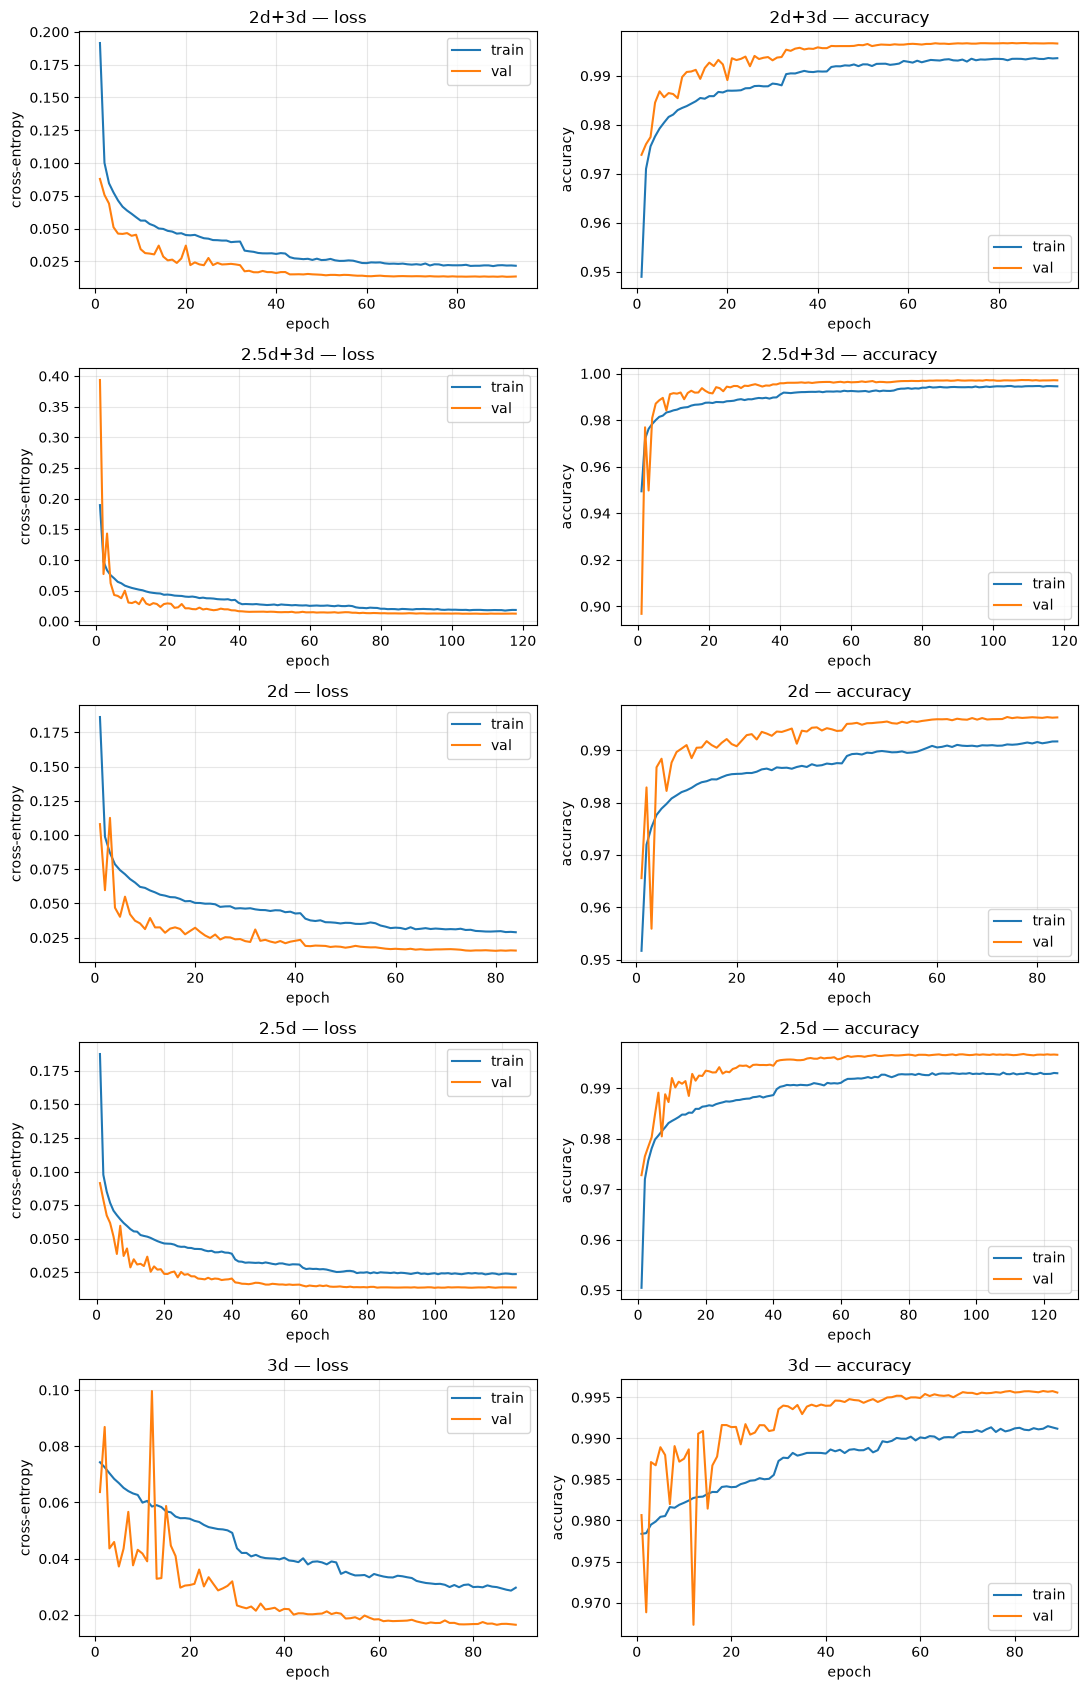

In [12]:
# history columns: train loss, train accuracy, val loss, val accuracy
fig, axes = plt.subplots(len(MODES), 2, figsize=(11, 3.4 * len(MODES)), squeeze=False)
for (ax_loss, ax_acc), mode in zip(axes, MODES):
    h = runs[mode]["history"]
    epochs = range(1, len(h) + 1)
    ax_loss.plot(epochs, h[:, 0], label="train")
    ax_loss.plot(epochs, h[:, 2], label="val")
    ax_loss.set_ylabel("cross-entropy")
    ax_acc.plot(epochs, h[:, 1], label="train")
    ax_acc.plot(epochs, h[:, 3], label="val")
    ax_acc.set_ylabel("accuracy")
    for ax, name in ((ax_loss, "loss"), (ax_acc, "accuracy")):
        ax.set_title(f"{mode} \u2014 {name}")
        ax.set_xlabel("epoch")
        ax.grid(alpha=0.3)
        ax.legend()
fig.tight_layout()
plt.show()

## 3. Accuracy of the frames that reached the classifier

overall, of the confirmed frames

            all    left   right
2d+3d    87.66%  83.86%  91.20%
2.5d+3d  87.57%  84.50%  90.43%
2d       87.30%  83.10%  91.20%
2.5d     87.05%  82.34%  91.44%
3d       86.04%  82.72%  89.13%

per letter, of the confirmed frames, worst first by 2d+3d

  2d+3d             2.5d+3d                2d             2.5d                3d            
    all  left right     all  left right   all  left right  all  left right   all  left right
M   68%   58%   78%     67%   55%   79%   71%   56%   86%  76%   67%   84%   72%   59%   86%
N   70%   55%   94%     62%   43%   91%   65%   49%   91%  67%   49%   94%   57%   41%   81%
R   71%   59%   81%     70%   63%   76%   74%   56%   90%  73%   56%   88%   68%   66%   70%
I   74%   88%   61%     72%   88%   57%   67%   82%   53%  70%   83%   57%   63%   70%   57%
X   76%   74%   78%     76%   68%   83%   69%   72%   67%  68%   63%   72%   70%   69%   71%
A   80%   62%   94%     88%   80%   94%   83%   71%   92%  83% 

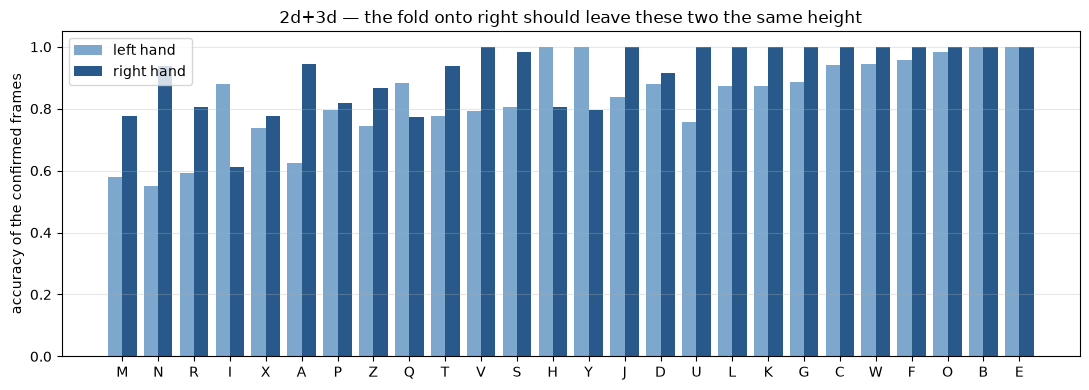

In [15]:
# Everything below is marked out of the frames that reached the classifier, so the
# detector's misses are set aside and what remains is the model's own doing; section 1
# holds the other denominator. Left and right are given apart as well as together,
# because the fold onto right happens before the model sees a hand: a gap between
# those two columns is the fold going wrong, not one hand being harder to read.
letters = sorted(set(TRUTH.tolist()))
of = {c: TRUTH == c for c in letters}
LEFT = runs[RANKED[0]]["left"].astype(bool)
HANDS = {"all": np.ones(N, bool), "left": LEFT, "right": ~LEFT}


def confirmed_acc(mode, rows):
    """Share of the confirmed frames within `rows` that came out the right letter."""
    d = runs[mode]
    sure = rows & (d["palm"] >= PALM_MIN) & (d["presence"] >= PRESENCE_MIN)
    return (d["y_true"] == d["y_pred"])[sure].mean() if sure.any() else np.nan


def show(df, places=0):
    """-> the same frame as percentage strings, with a dash where nothing was scored."""
    return df.apply(lambda s: s.map(
        lambda v: "-" if np.isnan(v) else f"{v:.{places}%}"))


overall = pd.DataFrame({h: [confirmed_acc(m, rows) for m in RANKED]
                        for h, rows in HANDS.items()}, index=RANKED)
print("overall, of the confirmed frames\n")
print(show(overall, 2).to_string())

per = pd.DataFrame({(m, h): [confirmed_acc(m, of[c] & rows) for c in letters]
                    for m in RANKED for h, rows in HANDS.items()}, index=letters)
per = per.sort_values((RANKED[0], "all"))
print(f"\nper letter, of the confirmed frames, worst first by {RANKED[0]}\n")
print(show(per).to_string())

best = RANKED[0]
x = np.arange(len(per.index))
fig, ax = plt.subplots(figsize=(11, 4))
for off, hand, shade in ((-0.2, "left", "#7da7cc"), (0.2, "right", "#28598a")):
    ax.bar(x + off, [confirmed_acc(best, of[c] & HANDS[hand]) for c in per.index],
           0.4, label=f"{hand} hand", color=shade)
ax.set_xticks(x, per.index)
ax.set_ylim(0, 1.05)
ax.set_ylabel("accuracy of the confirmed frames")
ax.set_title(f"{best} \u2014 the fold onto right should leave these two the same height")
ax.grid(axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## 4. Setup

In [14]:
d = runs[MODES[0]]
hidden = " \u2192 ".join(str(int(h)) for h in d["hidden"])
print(f"MLP   input \u2192 [Linear \u2192 BatchNorm \u2192 ReLU \u2192 "
      f"Dropout({float(d['dropout'])})] per hidden layer \u2192 Linear \u2192 "
      f"{len(letters)} classes")
print(f"hidden {hidden}   Adam lr {float(d['lr'])}   batch {int(d['batch_size'])}   "
      f"cross-entropy   early stopping on val accuracy")
print("\ninput width: " + "   ".join(
    f"{m} {int(runs[m]['dims'])}" for m in sorted(runs, key=lambda m: int(runs[m]["dims"]))))

MLP   input → [Linear → BatchNorm → ReLU → Dropout(0.3)] per hidden layer → Linear → 26 classes
hidden 256 → 128   Adam lr 0.001   batch 64   cross-entropy   early stopping on val accuracy

input width: 2d 42   2.5d 63   3d 63   2d+3d 105   2.5d+3d 126
